/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "
/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


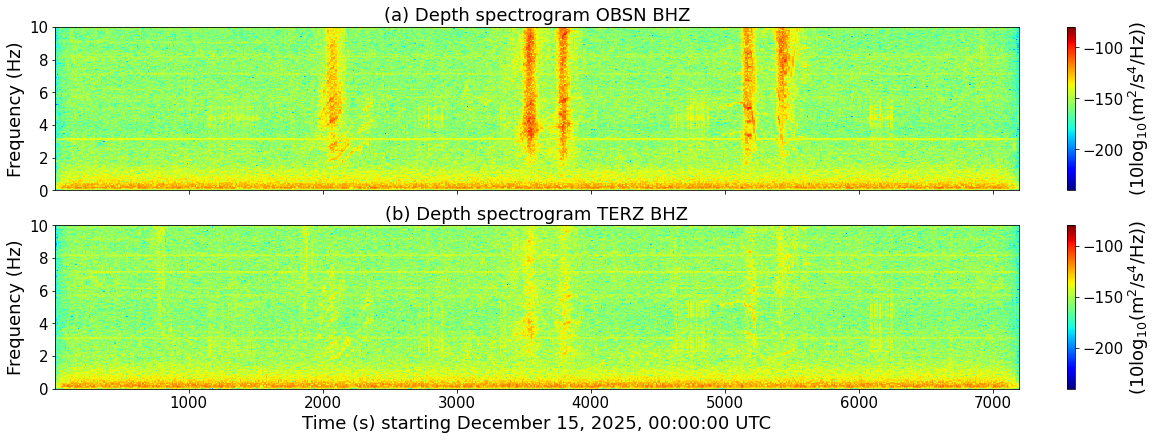

In [43]:
# script written to visualize the spectrogram between the surface and the borehole sensor
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp
import datetime

from obspy import read_inventory, UTCDateTime
from obspy.clients.filesystem.sds import Client


# ============================================================
# Configuration
# ============================================================
rootP2 = '/dcache/etseis/et/EMR/Data'
archiveP2 = Client(rootP2)

respPathA = '/dcache/etseis/et/EMR/Stations/Stations/NL.OBSN.xml'
respPathB = '/dcache/etseis/et/EMR/Stations/Stations/NL.TERZ.xml'
invNowA = read_inventory(respPathA)
invNowB = read_inventory(respPathB)

preFilt = [0.05, 0.1, 16, 18]

network = 'NL'
stationSurf = 'OBSN'
stationBH = 'TERZ'
channel_surface = 'BHZ'
channel_borehole = 'BHZ'
loc_surface = '01'
loc_borehole = '01'

# one hour example
yearNow = 2025
julday = 349
hour0 = 0

A = datetime.datetime(yearNow, 1, 1) + datetime.timedelta(days=julday - 1)
Start = UTCDateTime(A.year, A.month, A.day, hour0, 0, 0)
End = Start + 7200


# ============================================================
# Helpers
# ============================================================
def fetch_corrected_trace(station, channel, location, invNow, starttime, endtime, use_prefilt):
    st = archiveP2.get_waveforms(
        station=station,
        channel=channel,
        network=network,
        location=location,
        starttime=starttime,
        endtime=endtime
    )
    if not st:
        return None, None

    tr = st[0].copy()
    tr.trim(starttime=starttime, endtime=endtime, pad=True, fill_value=0)

    remove_kwargs = dict(
        inventory=invNow,
        output='ACC',
        zero_mean=True,
        hide_sensitivity_mismatch_warning=True
    )
    if use_prefilt:
        remove_kwargs["pre_filt"] = preFilt

    tr.remove_response(**remove_kwargs)
    tr.trim(starttime=starttime, endtime=endtime, pad=True, fill_value=0)

    return tr.data.astype(float), float(tr.stats.sampling_rate)


# ============================================================
# Load data
# ============================================================
x_bh, fs_bh = fetch_corrected_trace(
    station=stationBH,
    channel=channel_borehole,
    location=loc_borehole,
    invNow = invNowB,
    starttime=Start,
    endtime=End,
    use_prefilt=True
)

x_sf, fs_sf = fetch_corrected_trace(
    station=stationSurf,
    channel=channel_surface,
    location=loc_surface,
    invNow = invNowA,
    starttime=Start,
    endtime=End,
    use_prefilt=True
)

if x_bh is None:
    raise RuntimeError("No underground data found.")
if x_sf is None:
    raise RuntimeError("No surface data found.")

if fs_bh != fs_sf:
    raise RuntimeError("Sampling rates do not match.")

fs = fs_bh
t_wave = np.arange(len(x_bh)) / fs

# surface spectrogram for optional comparison
f_spec, t_spec, Sxx_sf = sp.spectrogram(
    x_sf,
    fs=fs,
    window='hann',
    nperseg=int(20 * fs),
    noverlap=int(10 * fs),
    detrend='constant',
    scaling='density',
    mode='psd'
)
Sxx_sf[Sxx_sf <= 0] = np.finfo(float).tiny

# surface spectrogram for optional comparison
_, _, Sxx_bh = sp.spectrogram(
    x_bh,
    fs=fs,
    window='hann',
    nperseg=int(20 * fs),
    noverlap=int(10 * fs),
    detrend='constant',
    scaling='density',
    mode='psd'
)
Sxx_bh[Sxx_bh <= 0] = np.finfo(float).tiny


# ============================================================
# Plot
# ============================================================
fig, axs = plt.subplots(
    2, 1,
    figsize=(16, 6),   # wider figure
    sharex=True,
    constrained_layout=True
)

# 1) underground spectrogram
pcm0 = axs[0].pcolormesh(
    t_spec, f_spec, 10 * np.log10(Sxx_sf),
    shading='auto',
    cmap='jet'
)
pcm0.set_clim(-240, -80)

axs[0].set_ylabel('Frequency (Hz)',fontsize=18)
axs[0].set_ylim(0,10)
axs[0].set_title('(a) Depth spectrogram '+ stationSurf+' '+ channel_surface,fontsize=18)
axs[0].tick_params(axis='both', labelsize=15)
cbar = fig.colorbar(pcm0, ax=axs[0], label='dB')
cbar.set_label(r'($10\log_{10}(\mathrm{m}^2/\mathrm{s}^4/\mathrm{Hz}$))', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# 2) underground spectrogram
pcm1 = axs[1].pcolormesh(
    t_spec, f_spec, 10 * np.log10(Sxx_bh),
    shading='auto',
    cmap='jet'
)
pcm1.set_clim(-240, -80)

axs[1].set_xlabel('Time (s) starting December 15, 2025, 00:00:00 UTC',fontsize=18)
axs[1].set_ylabel('Frequency (Hz)',fontsize=18)
axs[1].set_ylim(0,10)
axs[1].set_title('(b) Depth spectrogram '+ stationBH +' '+ channel_borehole,fontsize=18)
axs[1].tick_params(axis='both', labelsize=15)
cbar = fig.colorbar(pcm1, ax=axs[1], label='dB')
cbar.set_label(r'($10\log_{10}(\mathrm{m}^2/\mathrm{s}^4/\mathrm{Hz}$))', fontsize=18)
cbar.ax.tick_params(labelsize=15)

plt.show()
